In [1]:
print("hello world")

hello world


In [2]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated

from langgraph.prebuilt import ToolNode,tools_condition

from langchain_core.tools import tool


llm = ChatOllama(model="qwen3:4b")

In [ ]:
from ddgs import DDGS
@tool
def search_tool(query: str) -> str:
    """Executes a live search on DuckDuckGo and returns consolidated snippets."""
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=2))

        if not results:
            return f"No results found for search query: '{query}'"

        formatted_results = []

        for i, res in enumerate(results, 1):
            formatted_results.append(
                f"[{i}] {res['title']}\n"
                f"URL: {res['href']}\n"
                f"Snippet: {res['body']}\n"
            )

        return "\n".join(formatted_results)

    except Exception as e:
        return f"An error occurred while executing search: {str(e)}"


print(search_tool.invoke("which team won ipl 2026?"))

[1] 2026 Indian Premier League final - Wikipedia
URL: https://en.wikipedia.org/wiki/2026_Indian_Premier_League_final
Snippet: Royal Challengers Bengaluru won the toss and elected to field. · Royal Challengers Bengaluru won their second IPL title after 2025. They also became the third ...

[2] Indian Premier League - Wikipedia
URL: https://en.wikipedia.org/wiki/Indian_Premier_League
Snippet: The current champions are the Royal Challengers Bengaluru, who won the 2026 season after defeating the Gujarat Titans in the final. ... ↑ "First IPL winning ... History · Squads · Performance by teams · Finances

[3] IPL 2026 Fixtures, Live Score, Schedule, Points Table & News
URL: https://www.cricinfo.com/series/ipl-2026-1510719
Snippet: RCB Winner Royal Challengers Bengaluru. RCB won by 5 wickets … for Delhi Capitals in IPL 2026,



In [4]:
@tool
def calculator(first_num:float,second_num:float,operation:str)->dict:
    """
    perform a absic arithmetic operation on two number.
    support operation: add, sub, mul, div
    """
    try:
        if operation=="add":
            result=first_num+second_num
        elif operation=="sub":
            result=first_num-second_num;
        elif operation=="mul":
            result=round(first_num*second_num,2)
        elif operation=="div":
            if second_num==0:
                return{"error":"division by 0 not allowed"}
            result=round(first_num/second_num,2)
        else:
            return{"error":{"Unsupportable operation"}}
        return {"first_num":first_num,"second_num":second_num,"operation":operation,"result":result}
    except Exception as e:
        return {"error":str(e)}
        

In [5]:

tools=[search_tool,calculator]

llm_with_tool=llm.bind_tools(tools)

In [6]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [7]:
def chat_node(state:ChatState):
    """llm node that may answer or request a tool call"""
    messges=state["messages"]
    responce=llm_with_tool.invoke(messges)
    return {"messages":[responce]}

tool_node=ToolNode(tools)

In [20]:
graph=StateGraph(ChatState)

graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

In [21]:
graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")


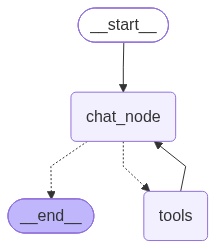

In [22]:
workflow=graph.compile()
workflow

In [25]:
out=workflow.invoke({"messages":HumanMessage(content="which team won ipl 2026?")})
print(out["messages"][-1].content)

KeyboardInterrupt: 